## Restaurant Ranking

A simple mean star rating can be misleading if a restaurant has 5.0 stars with only 2 reviews versus 4.7 stars with 500 reviews. We apply a Bayesian Average (m-estimate) to smooth the star ratings based on total review volume:

$$\text{Bayesian Rating} = \frac{v \cdot R + m \cdot C}{v + m}$$

Where:

$v$ = total reviews for the restaurant (Review_Count) 

$R$ = average star rating for the restaurant (Avg_Star_Rating)

$m$ = minimum threshold of reviews required (e.g., 25th percentile of review counts)

$C$ = prior global mean star rating across all restaurants

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Define paths
master_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(master_dir, "outputs")

# Load exported deliverables from the ABSA notebook
restaurant_summary = pd.read_csv(os.path.join(data_dir, "restaurant_aspect_summary.csv"))
reviews_df = pd.read_csv(os.path.join(data_dir, "reviews_with_absa_opinions.csv"))
absa_pairs = pd.read_csv(os.path.join(data_dir, "absa_sentiment_pairs.csv"))

print("✓ All data successfully loaded!")
print(f"Restaurants count: {len(restaurant_summary)}")
print(f"Total reviews:     {len(reviews_df)}")
print(f"ABSA pairs count:  {len(absa_pairs)}")

✓ All data successfully loaded!
Restaurants count: 3058
Total reviews:     96606
ABSA pairs count:  128279


## Bayesian Star Rating

In [3]:
## Part 1: Bayesian Average Smoothing for Star Ratings

# Identify global parameters
C = restaurant_summary['Avg_Star_Rating'].mean()
m = restaurant_summary['Review_Count'].quantile(0.25)  # Threshold minimum reviews

def compute_bayesian_rating(row, m, C):
    v = row['Review_Count']
    R = row['Avg_Star_Rating']
    return (v / (v + m)) * R + (m / (v + m)) * C

restaurant_summary['Bayesian_Star_Rating'] = restaurant_summary.apply(
    compute_bayesian_rating, axis=1, args=(m, C)
)

# Fill missing aspect sentiment averages with 0.0 (neutral sentiment)
aspect_cols = [col for col in restaurant_summary.columns if col.startswith('Avg_Aspect_')]
restaurant_summary[aspect_cols] = restaurant_summary[aspect_cols].fillna(0.0)

print(f"Global average rating (C): {C:.2f}")
print(f"Minimum review threshold (m): {m:.0f}")
restaurant_summary[['Restaurant', 'Review_Count', 'Avg_Star_Rating', 'Bayesian_Star_Rating']].head()

Global average rating (C): 3.07
Minimum review threshold (m): 3


,Restaurant,Review_Count,Avg_Star_Rating,Bayesian_Star_Rating
0,'D' Selera Kelate,7,3.000,3.020
1,101 Food Center,6,3.333,3.244
2,103 Coffee Workshop,6,3.333,3.244
3,16th St Cafe,1,2.000,2.799
4,16th St. Cafe,24,3.583,3.526


## Weighted Ranking Function

In [5]:
## Part 2: Weighted Ranking Function

def rank_restaurants(summary_df, star_weight=0.4, aspect_weights=None):
    
    df = summary_df.copy()
    
    # Default aspect weights if none provided
    if aspect_weights is None:
        aspect_weights = {
            'Avg_Aspect_Food': 0.25,
            'Avg_Aspect_Service': 0.15,
            'Avg_Aspect_Price': 0.10,
            'Avg_Aspect_Ambience': 0.05,
            'Avg_Aspect_Cleanliness': 0.03,
            'Avg_Aspect_Location': 0.01,
            'Avg_Aspect_Waiting Time': 0.01
        }
    
    # Normalize Bayesian Star Rating from [1, 5] scale to [0, 1] scale
    df['Norm_Star_Rating'] = (df['Bayesian_Star_Rating'] - 1) / 4.0
    
    # Normalize Aspect Scores from [-1, 1] scale to [0, 1] scale
    for col in aspect_weights.keys():
        if col in df.columns:
            df[f'Norm_{col}'] = (df[col] + 1.0) / 2.0
        else:
            df[f'Norm_{col}'] = 0.5  # default neutral if aspect missing
            
    # Calculate aspect composite score
    df['Aspect_Composite_Score'] = 0.0
    total_aspect_weight = sum(aspect_weights.values())
    
    for col, w in aspect_weights.items():
        df['Aspect_Composite_Score'] += df[f'Norm_{col}'] * (w / total_aspect_weight)
        
    # Calculate Final Ranking Score (0.0 to 100.0 scale)
    df['Final_Score'] = (
        (star_weight * df['Norm_Star_Rating']) + 
        ((1.0 - star_weight) * df['Aspect_Composite_Score'])
    ) * 100.0
    
    # Sort and rank
    ranked_df = df.sort_values(by='Final_Score', ascending=False).reset_index(drop=True)
    ranked_df['Rank'] = ranked_df.index + 1
    
    return ranked_df

# Generate default top-ranked restaurants
ranked_restaurants = rank_restaurants(restaurant_summary)

print("="*70)
print("TOP 10 RESTAURANTS (DEFAULT OVERALL RANKING)")
print("="*70)
display(ranked_restaurants[['Rank', 'Restaurant', 'Final_Score', 'Bayesian_Star_Rating', 'Review_Count']].head(10))

TOP 10 RESTAURANTS (DEFAULT OVERALL RANKING)


,Rank,Restaurant,Final_Score,Bayesian_Star_Rating,Review_Count
0,1,The Bikalan,75.406,4.566,15
1,2,Antipodean Bukit Bintang,75.187,4.450,13
2,3,Korean Seoul Restaurant,75.067,4.511,15
3,4,Alhamdulillah Restaurant,74.687,4.512,56
4,5,Cheang Kee,74.206,4.444,29
5,6,Two Frenchies Cafe Bistrot,73.984,4.471,25
6,7,Sarti Supperclub,73.846,4.274,5
7,8,Chambers Grill,73.047,4.372,97
8,9,Cielo Sky Dining & Lounge,72.848,4.305,60
9,10,Canopy Rooftop Bar and Lounge,72.806,4.348,173


## Aspect Ranking Function

In [6]:
## Part 3: Specialized Aspect Ranking Function

def get_top_by_aspect(summary_df, aspect_name, top_n=5, min_reviews=10):
    col_name = f'Avg_Aspect_{aspect_name}'
    if col_name not in summary_df.columns:
        print(f"Error: Aspect '{aspect_name}' not found.")
        return None
        
    filtered = summary_df[summary_df['Review_Count'] >= min_reviews].copy()
    ranked = filtered.sort_values(by=col_name, ascending=False).reset_index(drop=True)
    ranked['Rank'] = ranked.index + 1
    
    return ranked[['Rank', 'Restaurant', col_name, 'Avg_Star_Rating', 'Review_Count']].head(top_n)

# Example: Get top 5 restaurants for Service and Price
print("\n--- TOP 5 FOR SERVICE ---")
display(get_top_by_aspect(restaurant_summary, 'Service', top_n=5))

print("\n--- TOP 5 BEST VALUE FOR MONEY (PRICE) ---")
display(get_top_by_aspect(restaurant_summary, 'Price', top_n=5))


--- TOP 5 FOR SERVICE ---


,Rank,Restaurant,Avg_Aspect_Service,Avg_Star_Rating,Review_Count
0,1,Restoran Krishna Bhawan,0.625,2.538,26
1,2,August Cafe,0.625,3.000,16
2,3,The Beach Grill,0.599,3.750,16
3,4,SUPE Vegan - Georgetown Branch,0.592,4.062,16
4,5,Puree Juice,0.586,4.600,10



--- TOP 5 BEST VALUE FOR MONEY (PRICE) ---


,Rank,Restaurant,Avg_Aspect_Price,Avg_Star_Rating,Review_Count
0,1,Olive Kitchen + Bar,0.637,3.148,27
1,2,Paradise Dynasty @ Bangsar Village II,0.625,3.500,54
2,3,sarvana bhavan,0.625,3.154,13
3,4,Verandah Lounge,0.625,4.250,28
4,5,WIP,0.625,3.129,31


## Qualitative Diagnostic Card

In [7]:
## Part 4: Detailed Qualitative Diagnostic Card

def generate_restaurant_report(restaurant_name):
    rest_data = ranked_restaurants[ranked_restaurants['Restaurant'] == restaurant_name]
    
    if len(rest_data) == 0:
        print(f"Restaurant '{restaurant_name}' not found.")
        return
        
    row = rest_data.iloc[0]
    print("=" * 70)
    print(f"RESTAURANT DIAGNOSTIC REPORT: {restaurant_name.upper()}")
    print("=" * 70)
    print(f"Overall Rank:          #{row['Rank']}")
    print(f"Final Score:           {row['Final_Score']:.2f} / 100")
    print(f"Bayesian Star Rating:  {row['Bayesian_Star_Rating']:.2f} ★")
    print(f"Total Reviews:         {row['Review_Count']}")
    print("-" * 70)
    print("ASPECT SENTIMENT BREAKDOWN:")
    
    aspect_cols = [c for c in row.index if c.startswith('Avg_Aspect_')]
    for col in aspect_cols:
        aspect = col.replace('Avg_Aspect_', '')
        score = row[col]
        sentiment_label = "Positive" if score > 0.1 else ("Negative" if score < -0.1 else "Neutral")
        print(f"  • {aspect:<15}: {score:+.3f} ({sentiment_label})")
        
    print("-" * 70)
    print("TOP POSITIVE OPINIONS MENTIONED:")
    pos_opinions = absa_pairs[(absa_pairs['Restaurant'] == restaurant_name) & 
                              (absa_pairs['Sentiment'] == 'Positive')]
    if len(pos_opinions) > 0:
        for idx, op in pos_opinions.head(3).iterrows():
            print(f"  ✓ [{op['Category']}] '{op['Target']}' -> '{op['Opinion_Expression']}'")
    else:
        print("  None found.")
        
    print("\nTOP NEGATIVE/CRITICAL OPINIONS MENTIONED:")
    neg_opinions = absa_pairs[(absa_pairs['Restaurant'] == restaurant_name) & 
                              (absa_pairs['Sentiment'] == 'Negative')]
    if len(neg_opinions) > 0:
        for idx, op in neg_opinions.head(3).iterrows():
            print(f"  ✗ [{op['Category']}] '{op['Target']}' -> '{op['Opinion_Expression']}'")
    else:
        print("  None found.")
    print("=" * 70)

# Run diagnostic for top ranked restaurant
top_restaurant = ranked_restaurants.iloc[0]['Restaurant']
generate_restaurant_report(top_restaurant)

RESTAURANT DIAGNOSTIC REPORT: THE BIKALAN
Overall Rank:          #1
Final Score:           75.41 / 100
Bayesian Star Rating:  4.57 ★
Total Reviews:         15
----------------------------------------------------------------------
ASPECT SENTIMENT BREAKDOWN:
  • Ambience       : +0.375 (Positive)
  • Cleanliness    : +0.000 (Neutral)
  • Food           : +0.409 (Positive)
  • Location       : +0.474 (Positive)
  • Price          : +0.000 (Neutral)
  • Service        : +0.440 (Positive)
  • Waiting Time   : +0.312 (Positive)
----------------------------------------------------------------------
TOP POSITIVE OPINIONS MENTIONED:
  ✓ [Ambience] 'atmosphere' -> 'great'
  ✓ [Food] 'food' -> 'delicious'
  ✓ [Location] 'location' -> 'peaceful'

TOP NEGATIVE/CRITICAL OPINIONS MENTIONED:
  None found.


## Visualizations

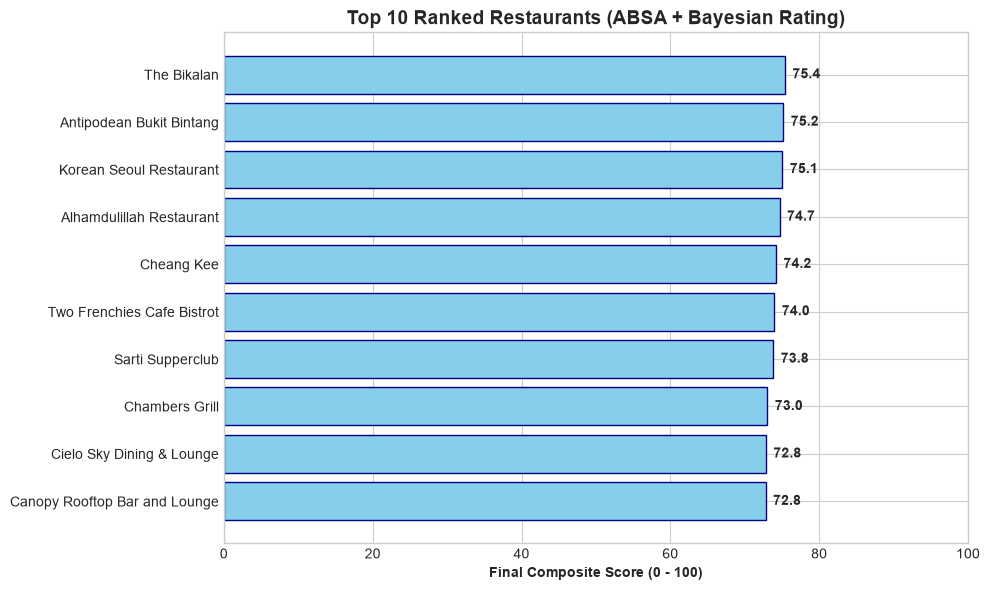

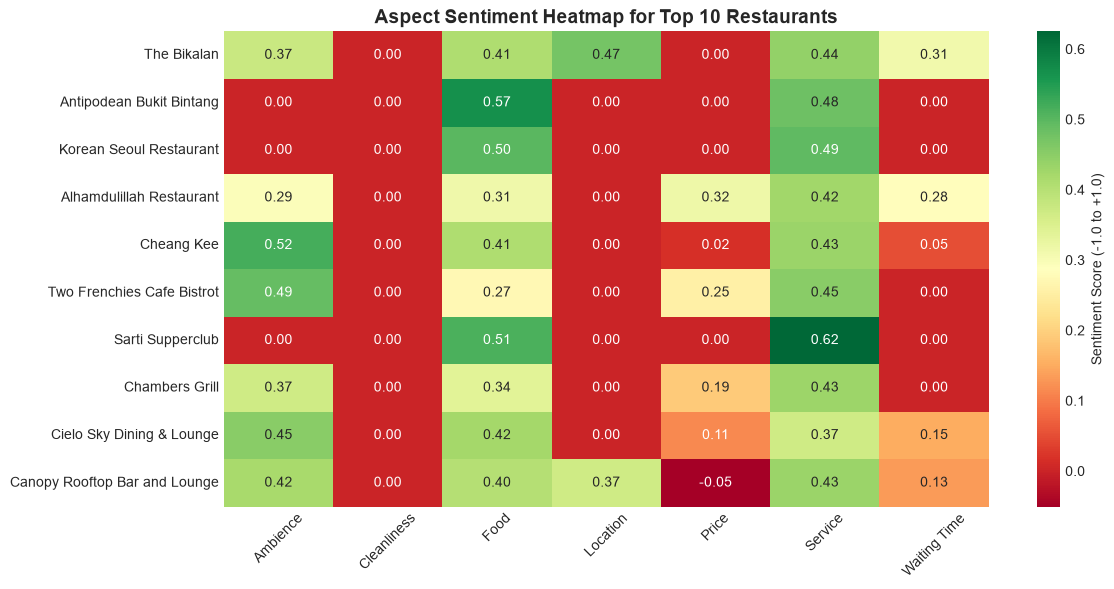

In [8]:
## Part 5: Visualizations

# 1. Top 10 Ranked Restaurants Horizontal Bar Plot
plt.figure(figsize=(10, 6))
top10 = ranked_restaurants.head(10).sort_values(by='Final_Score', ascending=True)

plt.barh(top10['Restaurant'], top10['Final_Score'], color='skyblue', edgecolor='navy')
plt.xlabel('Final Composite Score (0 - 100)', fontweight='bold')
plt.title('Top 10 Ranked Restaurants (ABSA + Bayesian Rating)', fontsize=14, fontweight='bold')
plt.xlim(0, 100)

for index, value in enumerate(top10['Final_Score']):
    plt.text(value + 1, index, f"{value:.1f}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03_top10_restaurant_rankings.png', dpi=300)
plt.show()

# 2. Aspect Heatmap for Top 10 Restaurants
plt.figure(figsize=(12, 6))
top10_matrix = ranked_restaurants.head(10).set_index('Restaurant')
heatmap_cols = [c for c in top10_matrix.columns if c.startswith('Avg_Aspect_')]
clean_cols = [c.replace('Avg_Aspect_', '') for c in heatmap_cols]

sns.heatmap(
    top10_matrix[heatmap_cols], 
    annot=True, 
    cmap='RdYlGn', 
    fmt='.2f', 
    xticklabels=clean_cols,
    cbar_kws={'label': 'Sentiment Score (-1.0 to +1.0)'}
)
plt.title('Aspect Sentiment Heatmap for Top 10 Restaurants', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/03_top10_aspect_heatmap.png', dpi=300)
plt.show()

## Comparison of Ranking Methods

COMPARISON: OLD METHOD vs. NEW ABSA + BAYESIAN METHOD

--- TOP 10 ACCORDING TO NEW METHOD (WITH OLD RANK COMPARISON) ---


,Restaurant,Review_Count,Avg_Star_Rating,Old_Rank,New_Rank,Rank_Shift,Final_Score
0,The Bikalan,15,4.867,218,1,217,75.406
1,Antipodean Bukit Bintang,13,4.769,236,2,234,75.187
2,Korean Seoul Restaurant,15,4.800,219,3,216,75.067
3,Alhamdulillah Restaurant,56,4.589,74,4,70,74.687
4,Cheang Kee,29,4.586,147,5,142,74.206
5,Two Frenchies Cafe Bistrot,25,4.640,160,6,154,73.984
6,Sarti Supperclub,5,5.000,337,7,330,73.846
7,Chambers Grill,97,4.412,38,8,30,73.047
8,Cielo Sky Dining & Lounge,60,4.367,68,9,59,72.848
9,Canopy Rooftop Bar and Lounge,173,4.370,10,10,0,72.806



--- TOP 10 ACCORDING TO OLD METHOD (WITH NEW RANK COMPARISON) ---


,Restaurant,Review_Count,Avg_Star_Rating,Old_Rank,New_Rank,Rank_Shift,Final_Score
0,Ishin Japanese Dining,362,3.597,1,244,-243,63.205
1,Dining In The Dark KL,318,4.066,2,70,-68,67.670
2,Iketeru Restaurant,206,4.136,3,35,-32,69.841
3,The Baboon House,203,3.926,4,79,-75,67.253
4,Living Room Cafe Bar & Gallery,197,3.609,5,138,-133,65.449
5,Antipodean @ Atria,191,3.550,6,246,-240,63.176
6,Antipodean Cafe,185,3.843,7,107,-100,66.161
7,Restoran Kacang Pool Haji,184,3.592,8,417,-409,61.008
8,Andrew's Kampung,180,3.706,9,119,-110,65.817
9,Canopy Rooftop Bar and Lounge,173,4.370,10,10,0,72.806


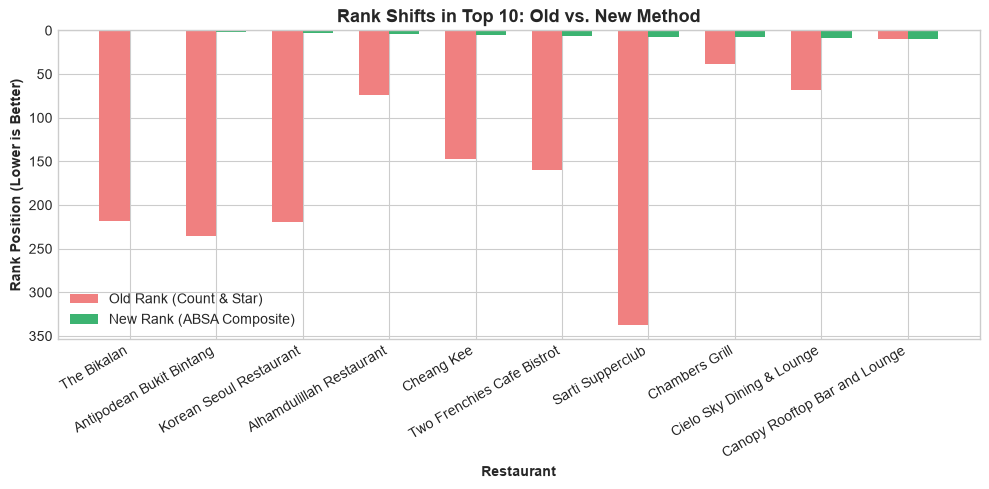

In [12]:
## Part 7: Method Comparison (Old Sorting vs. New ABSA-Bayesian Ranking)

# 1. Filter restaurants with > 3.5 average rating, then sort by Review Count and Star Rating
filtered_summary = restaurant_summary[restaurant_summary['Avg_Star_Rating'] > 3.5].copy()

# 2. Compute Old Rank using your original method:
old_ranked = (
    filtered_summary
    .sort_values(by=["Review_Count", "Avg_Star_Rating"], ascending=[False, False])
    .reset_index(drop=True)
)
old_ranked['Old_Rank'] = old_ranked.index + 1

# 2. Extract key columns from New Rank (already stored in `ranked_restaurants`)
new_ranked = ranked_restaurants[['Restaurant', 'Rank', 'Final_Score', 'Bayesian_Star_Rating']].copy()
new_ranked = new_ranked.rename(columns={'Rank': 'New_Rank'})

# 3. Merge both ranking outputs for direct comparison
comparison_df = old_ranked.merge(new_ranked, on='Restaurant')

# Calculate rank change (Positive = Moved UP in new method, Negative = Dropped DOWN)
comparison_df['Rank_Shift'] = comparison_df['Old_Rank'] - comparison_df['New_Rank']

# Reorder columns for clean presentation
comparison_df = comparison_df[[
    'Restaurant', 'Review_Count', 'Avg_Star_Rating', 
    'Old_Rank', 'New_Rank', 'Rank_Shift', 'Final_Score'
]]

print("=" * 80)
print("COMPARISON: OLD METHOD vs. NEW ABSA + BAYESIAN METHOD")
print("=" * 80)

# Display Top 10 according to the NEW Method
print("\n--- TOP 10 ACCORDING TO NEW METHOD (WITH OLD RANK COMPARISON) ---")
display(comparison_df.sort_values('New_Rank').head(10).reset_index(drop=True))

# Display Top 10 according to the OLD Method
print("\n--- TOP 10 ACCORDING TO OLD METHOD (WITH NEW RANK COMPARISON) ---")
display(comparison_df.sort_values('Old_Rank').head(10).reset_index(drop=True))

# 4. Visualization: Rank Shift Comparison
plt.figure(figsize=(10, 5))
top_comparison = comparison_df.sort_values('New_Rank').head(10)

x = np.arange(len(top_comparison))
width = 0.35

plt.bar(x - width/2, top_comparison['Old_Rank'], width, label='Old Rank (Count & Star)', color='lightcoral')
plt.bar(x + width/2, top_comparison['New_Rank'], width, label='New Rank (ABSA Composite)', color='mediumseagreen')

plt.xlabel('Restaurant', fontweight='bold')
plt.ylabel('Rank Position (Lower is Better)', fontweight='bold')
plt.title('Rank Shifts in Top 10: Old vs. New Method', fontsize=13, fontweight='bold')
plt.xticks(x, top_comparison['Restaurant'], rotation=30, ha='right')
plt.gca().invert_yaxis()  # Invert axis so Rank #1 is at the top
plt.legend()
plt.tight_layout()
plt.show()